In [1]:
import pandas as pd

url = "https://www.openml.org/data/get_csv/1595261/phpMawTba"

df = pd.read_csv(url, na_values=["?", " ?"])

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
df.shape

(48842, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  class           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


In [7]:
# Drop the unnecessary column
df.drop(columns=['fnlwgt'], inplace=True)

# Insight:
# finalwgt is a survey/sample weight, not a useful feature for our
# income classification model, so we remove it.

In [8]:
df['class'].value_counts()


,count
class,
<=50K,37155
>50K,11687


# Insight:
# <=50K → 37,155 people
# >50K  → 11,687 people
#
# The dataset is imbalanced because there are many more <=50K
# samples than >50K samples.

In [9]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns.drop('class')


In [10]:
df_categorical = df[categorical_cols]
df_numerical = df[numerical_cols]

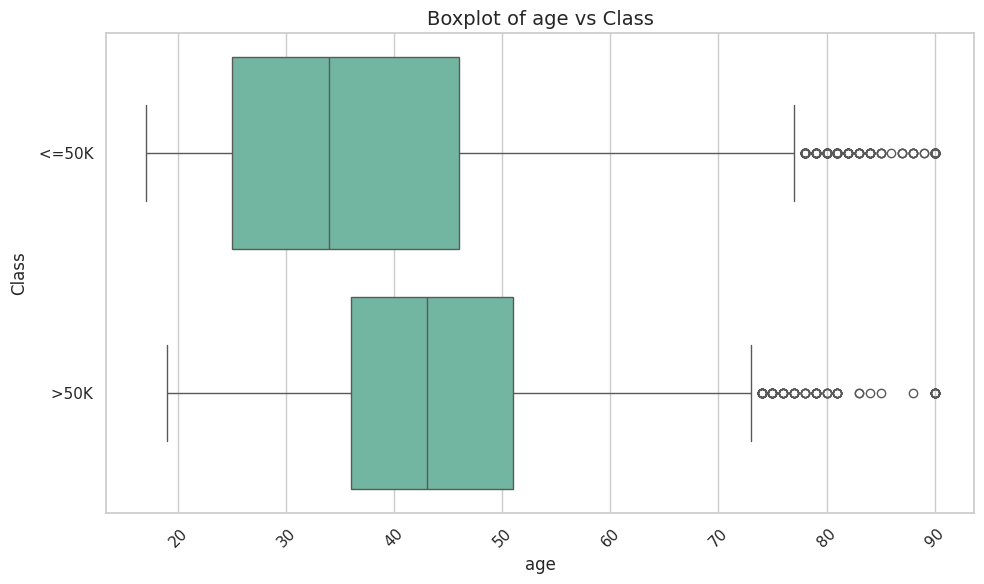

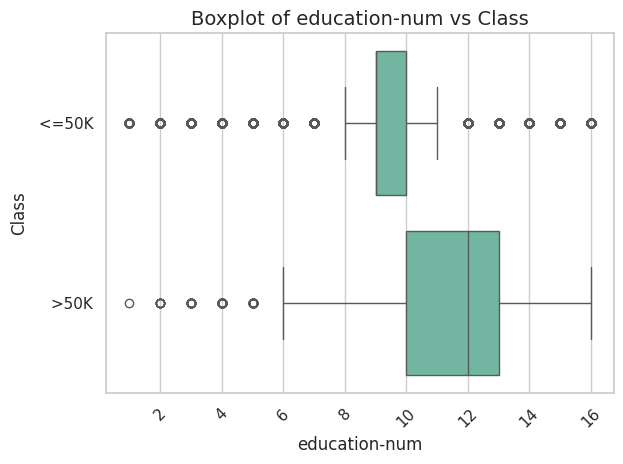

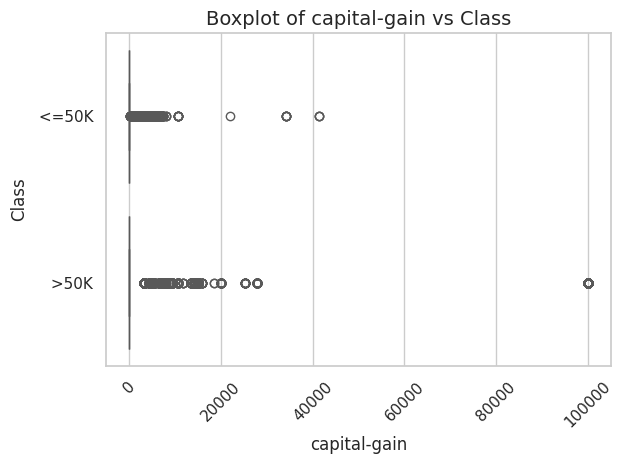

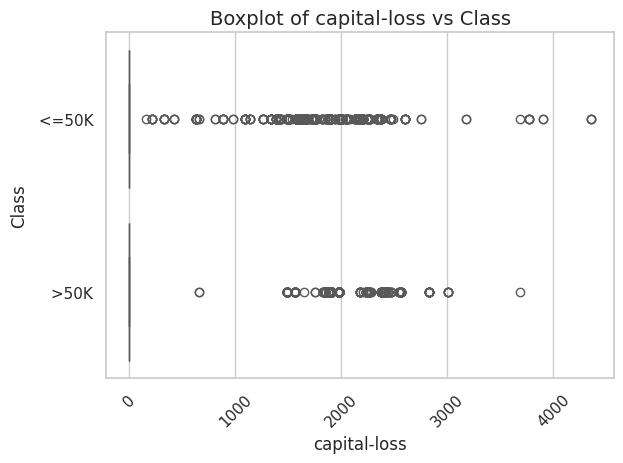

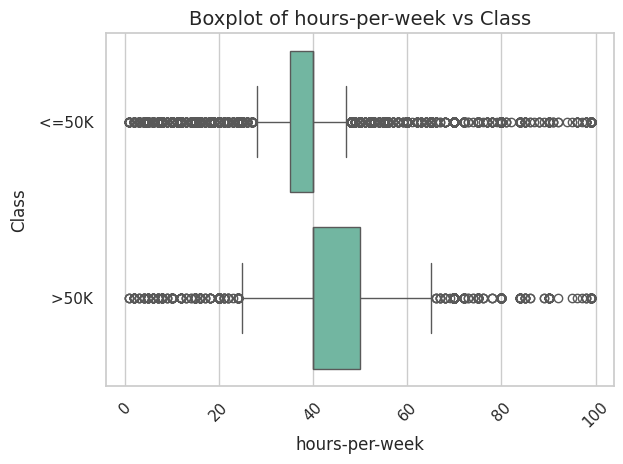

In [11]:
#template to plot any graph just replace .bexplot and x and y axis  and numeric col and cataegorical columns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style settings
sns.set_style("whitegrid")
sns.set_context("notebook")
sns.set_palette("Set2")

# Figure size
plt.figure(figsize=(10, 6))

for col in numerical_cols:
    sns.boxplot(
        data=df,
        x=col,
        y='class'
    )

    plt.title(f"Boxplot of {col} vs Class", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

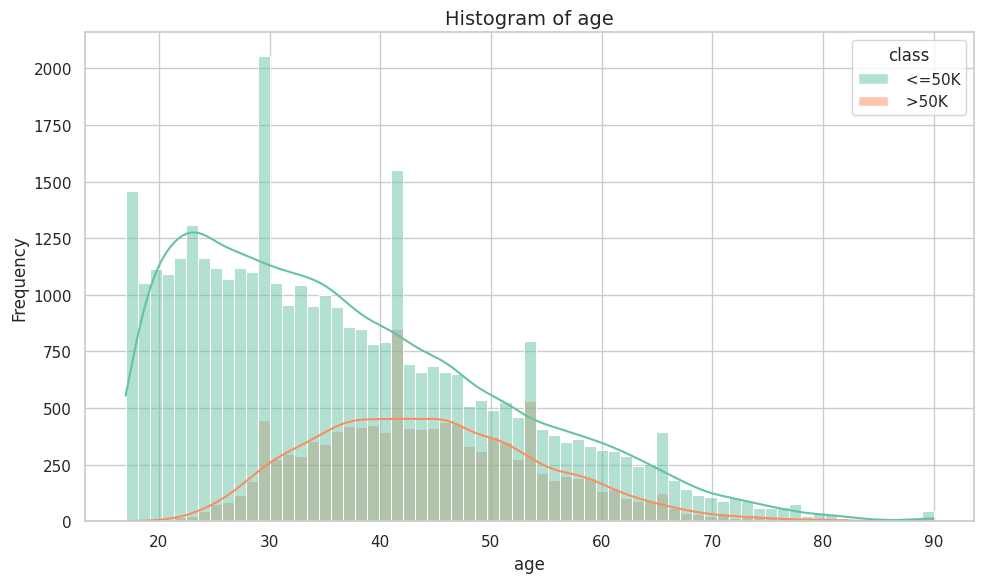

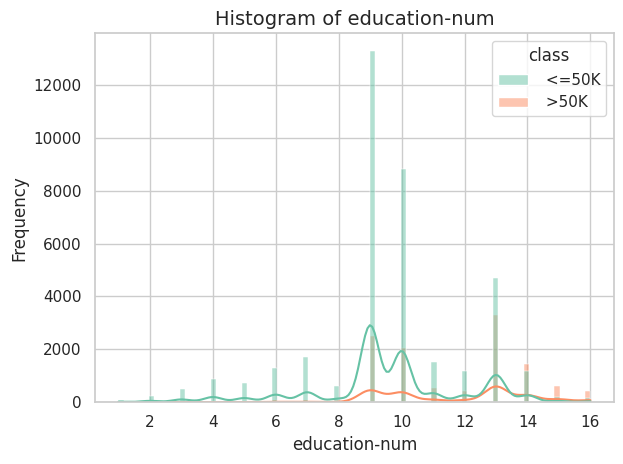

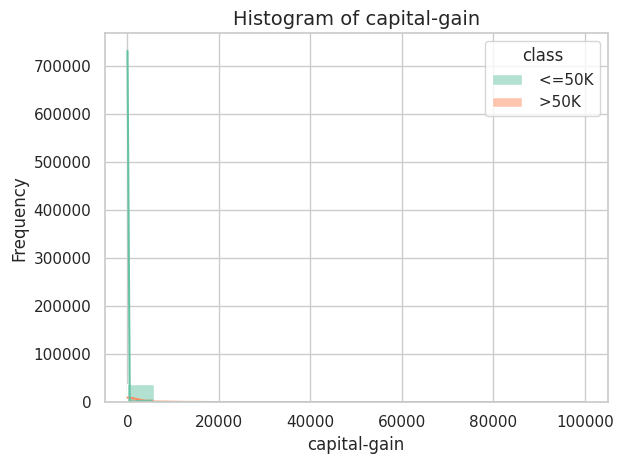

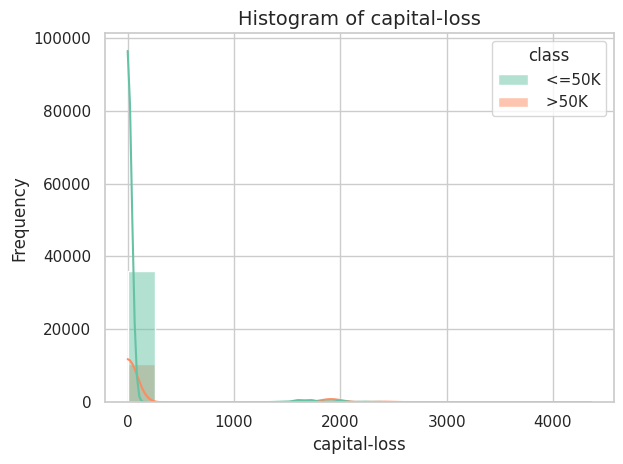

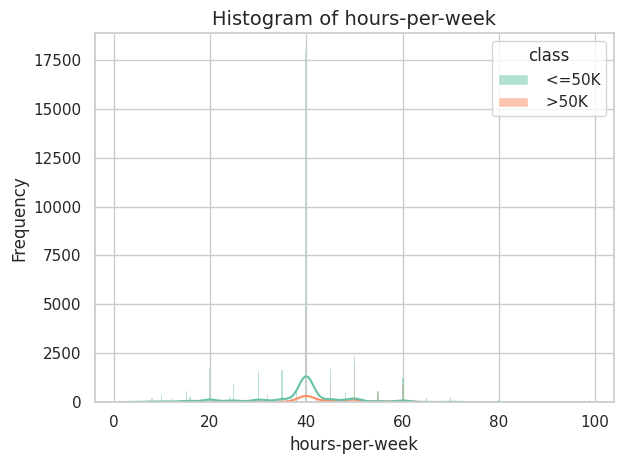

In [12]:
# Figure size
plt.figure(figsize=(10, 6))

# Histogram for each numerical column
for col in numerical_cols:
    sns.histplot(
        data=df,
        x=col,
        hue='class',
        kde=True,
        palette="Set2"
    )

    plt.title(f"Histogram of {col}", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

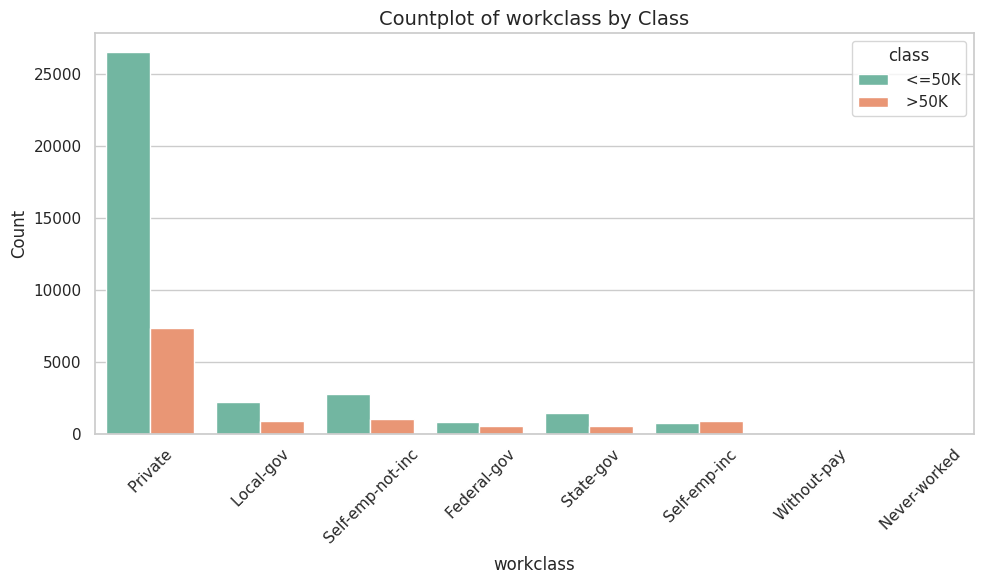

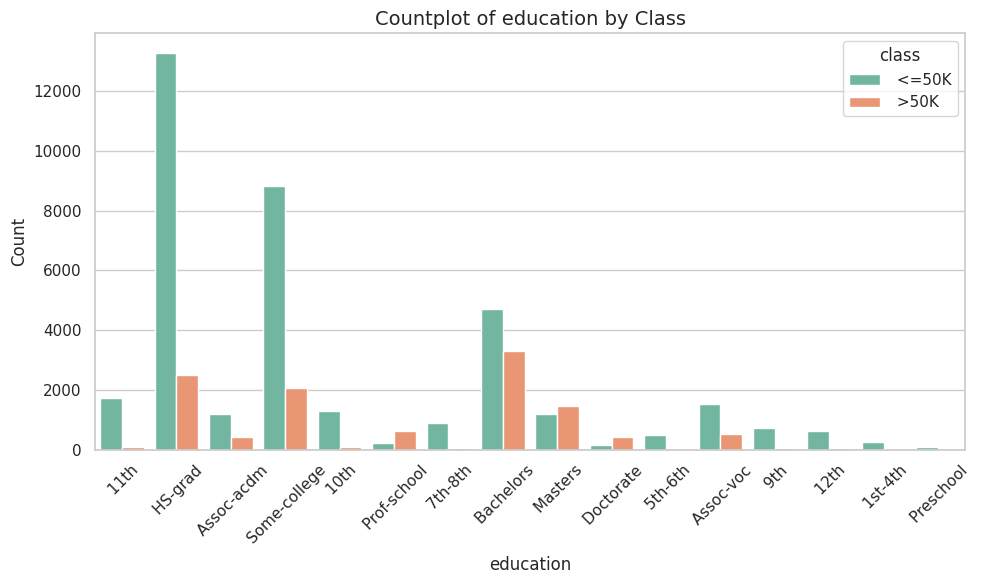

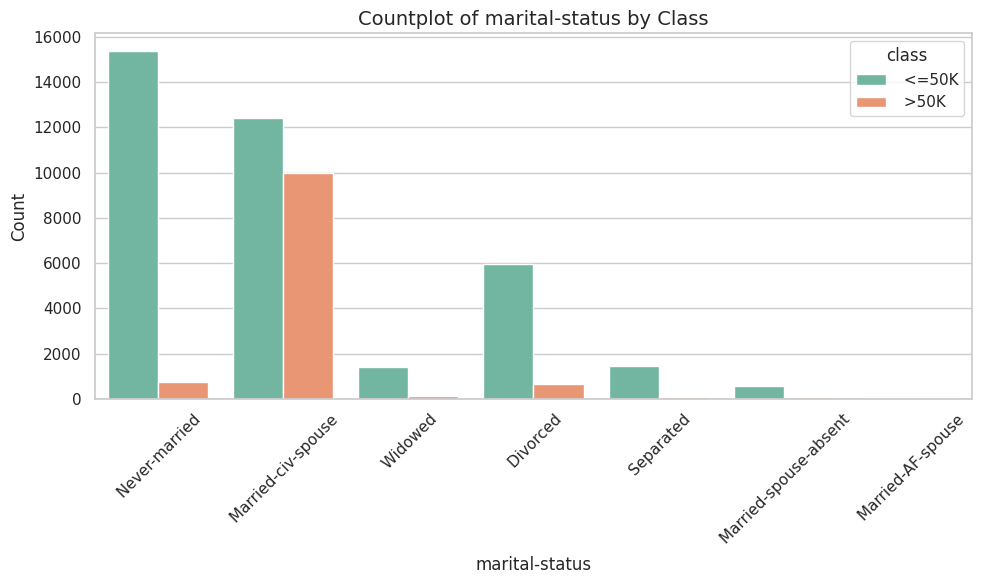

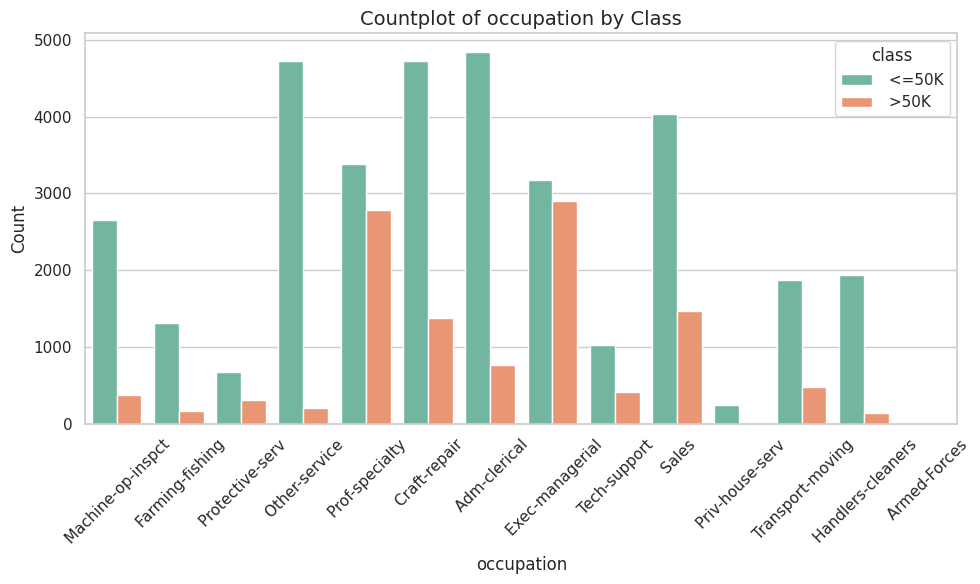

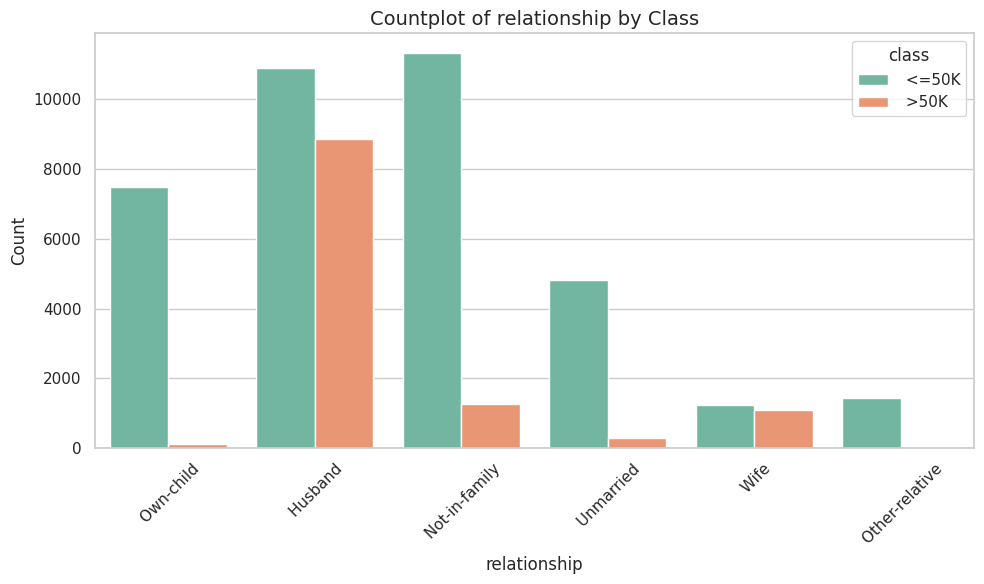

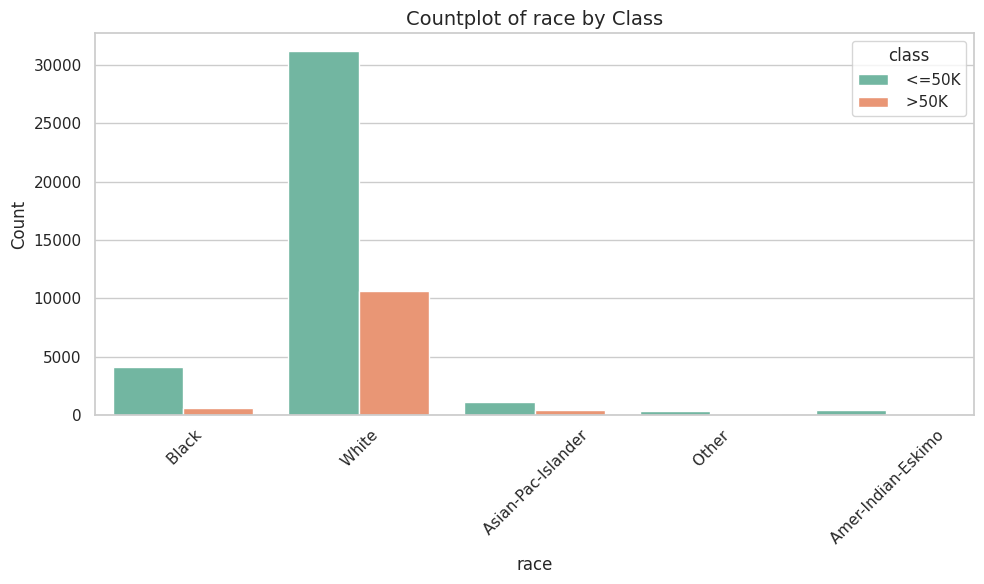

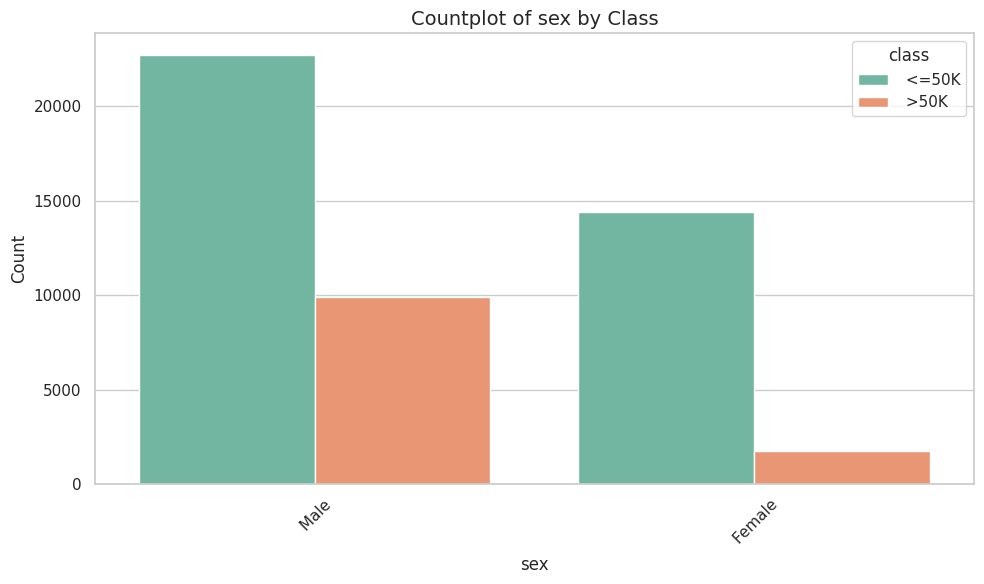

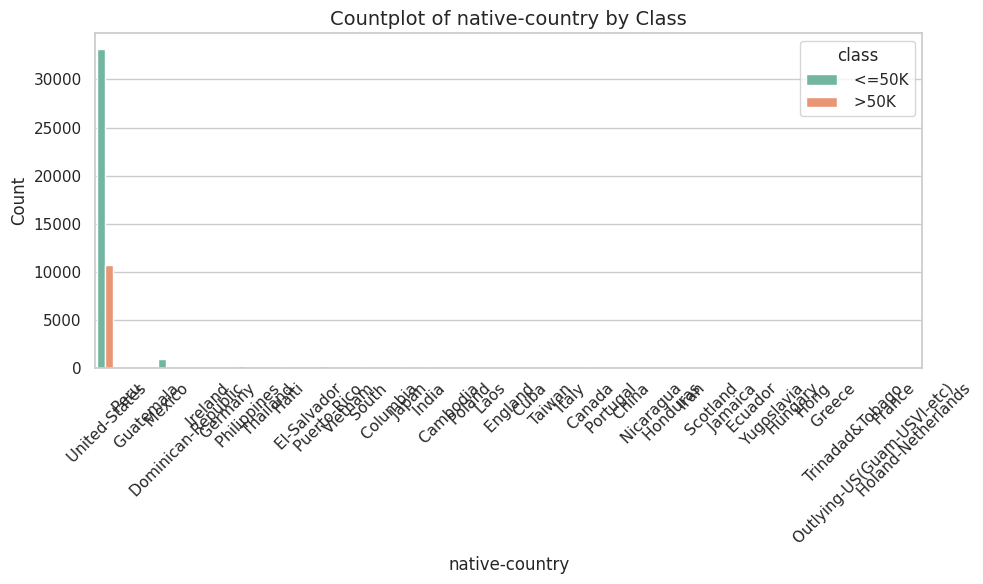

In [13]:
# Countplot for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x=col,
        hue='class',
        palette='Set2'
    )

    plt.title(f"Countplot of {col} by Class", fontsize=14)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

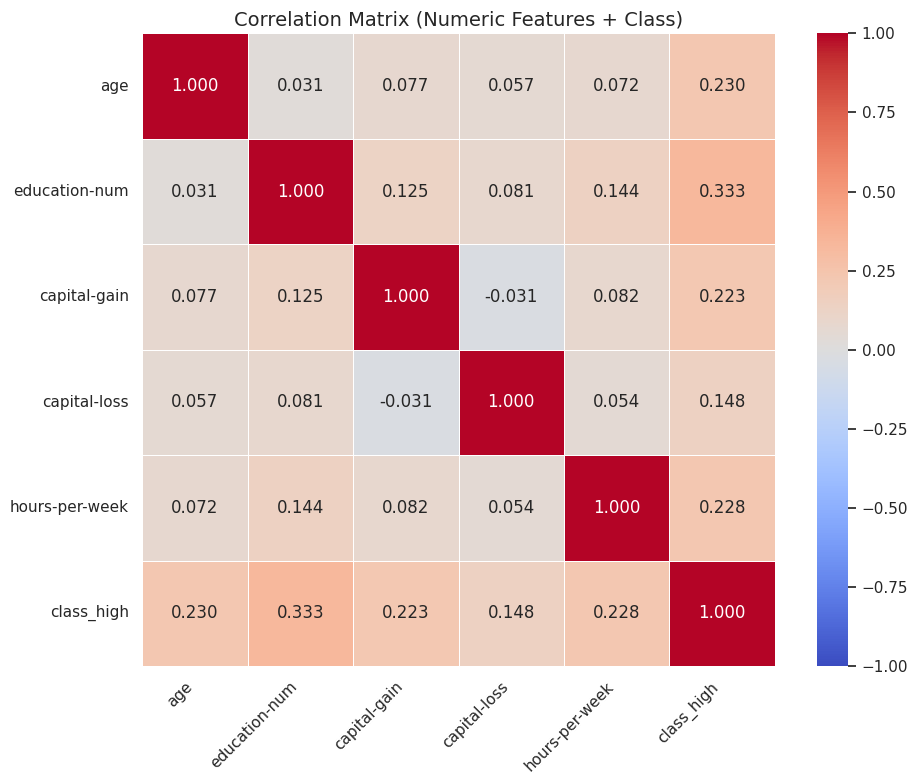

In [14]:
# Create binary class column
df_corr = df.copy()

df_corr['class'] = df_corr['class'].astype(str).str.strip()

df_corr['class_high'] = (df_corr['class'] == '>50K').astype(int)

# Select numerical features + class
corr_cols = list(numerical_cols) + ['class_high']
corr = df_corr[corr_cols].corr().round(3)

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title('Correlation Matrix (Numeric Features + Class)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
df.dropna(inplace=True)

In [16]:
# encode the target variable
# >50K = 1
# <=50K = 0

df['class'] = df['class'].str.strip().apply(
    lambda x: 1 if x == '>50K' else 0
)

print(df['class'].value_counts())

class
0    34014
1    11208
Name: count, dtype: int64


In [17]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df.shape)
print(df_encoded.shape)

(45222, 14)
(45222, 96)


In [18]:
# Convert boolean columns to integer
bool_cols = df_encoded.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 96 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   age                                         45222 non-null  int64
 1   education-num                               45222 non-null  int64
 2   capital-gain                                45222 non-null  int64
 3   capital-loss                                45222 non-null  int64
 4   hours-per-week                              45222 non-null  int64
 5   class                                       45222 non-null  int64
 6   workclass_ Local-gov                        45222 non-null  int64
 7   workclass_ Private                          45222 non-null  int64
 8   workclass_ Self-emp-inc                     45222 non-null  int64
 9   workclass_ Self-emp-not-inc                 45222 non-null  int64
 10  workclass_ State-gov                   

In [19]:
df_encoded.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,class,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38,9,0,0,50,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,28,12,0,0,40,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,44,10,7688,0,40,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
5,34,6,0,0,30,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [20]:
print(df_encoded['class'].value_counts())

class
0    34014
1    11208
Name: count, dtype: int64


In [21]:
# Split the df_encoded into train and test
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['class'])
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (36177, 95) (36177,)
Test shape: (9045, 95) (9045,)


In [22]:
# Check class distribution in training and testing data

print("Train class distribution:\n",
      y_train.value_counts(normalize=True))

print("\nTest class distribution:\n",
      y_test.value_counts(normalize=True))

Train class distribution:
 class
0    0.752163
1    0.247837
Name: proportion, dtype: float64

Test class distribution:
 class
0    0.752128
1    0.247872
Name: proportion, dtype: float64


In [23]:
X_train.columns

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_ Local-gov', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay', 'education_ 11th',
       'education_ 12th', 'education_ 1st-4th', 'education_ 5th-6th',
       'education_ 7th-8th', 'education_ 9th', 'education_ Assoc-acdm',
       'education_ Assoc-voc', 'education_ Bachelors', 'education_ Doctorate',
       'education_ HS-grad', 'education_ Masters', 'education_ Preschool',
       'education_ Prof-school', 'education_ Some-college',
       'marital-status_ Married-AF-spouse',
       'marital-status_ Married-civ-spouse',
       'marital-status_ Married-spouse-absent',
       'marital-status_ Never-married', 'marital-status_ Separated',
       'marital-status_ Widowed', 'occupation_ Armed-Forces',
       'occupation_ Craft-repair', 'occupation_ Exec-managerial',
       'occupation_ Farming-fishing

In [24]:
# Import required libraries

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# Train Logistic Regression model using all features

model_multi = LogisticRegression(max_iter=1000)

model_multi.fit(X_train, y_train)


# Prediction on test data

y_pred_multi = model_multi.predict(X_test)


# Predicted probabilities for ROC-AUC

y_prob_multi = model_multi.predict_proba(X_test)[:, 1]


# Confusion Matrix

cm_multi = confusion_matrix(y_test, y_pred_multi)

print("Confusion Matrix:")
print(cm_multi)


# Classification Report

cr_multi = classification_report(y_test, y_pred_multi)

print("\nClassification Report:")
print(cr_multi)


# Accuracy

accuracy_multi = accuracy_score(y_test, y_pred_multi)

print("Accuracy:", accuracy_multi)


# Precision

precision_multi = precision_score(y_test, y_pred_multi)

print("Precision:", precision_multi)


# Recall

recall_multi = recall_score(y_test, y_pred_multi)

print("Recall:", recall_multi)


# F1 Score

f1_multi = f1_score(y_test, y_pred_multi)

print("F1 Score:", f1_multi)


# ROC-AUC

roc_auc_multi = roc_auc_score(y_test, y_prob_multi)

print("ROC-AUC:", roc_auc_multi)

Confusion Matrix:
[[6301  502]
 [ 916 1326]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.73      0.59      0.65      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.84      0.84      9045

Accuracy: 0.8432283029297954
Precision: 0.725382932166302
Recall: 0.5914362176628011
F1 Score: 0.6515970515970516
ROC-AUC: 0.9012963662067018


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


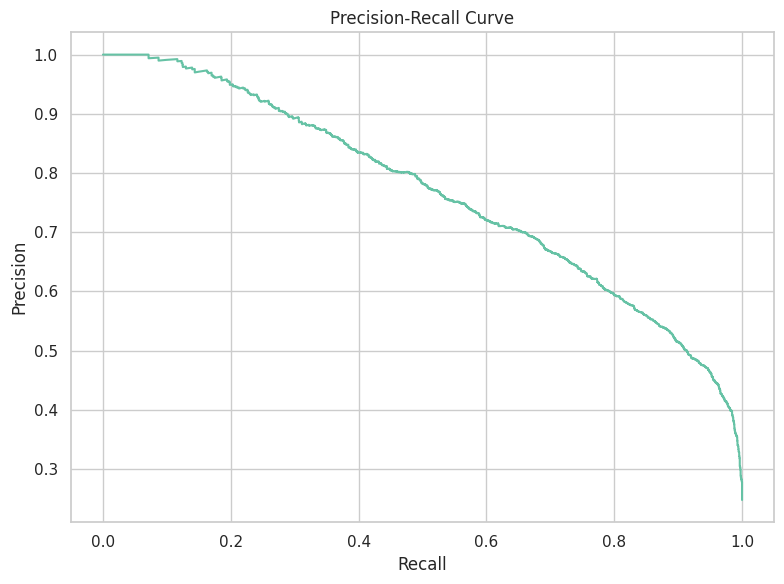

In [25]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob_multi
)

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)
plt.tight_layout()
plt.show()

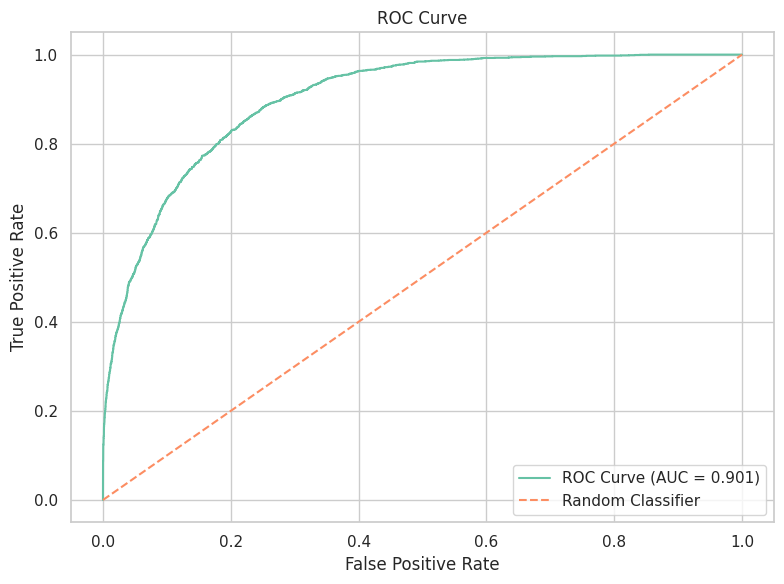

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_multi
)

roc_auc = roc_auc_score(y_test, y_prob_multi)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_multi.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

                               Feature  Coefficient
47             relationship_ Own-child    -1.685642
48             relationship_ Unmarried    -1.424705
38           occupation_ Other-service    -1.406513
8          workclass_ Self-emp-not-inc    -1.139313
35         occupation_ Farming-fishing    -1.082220
..                                 ...          ...
75               native-country_ Italy    -0.002895
94          native-country_ Yugoslavia    -0.002386
68  native-country_ Holand-Netherlands    -0.001595
3                         capital-loss     0.000636
2                         capital-gain     0.000313

[95 rows x 2 columns]


In [34]:
coefficients.head(10)

,Feature,Coefficient
47,relationship_ Own-child,-1.685642
48,relationship_ Unmarried,-1.424705
38,occupation_ Other-service,-1.406513
8,workclass_ Self-emp-not-inc,-1.139313
35,occupation_ Farming-fishing,-1.082220
79,native-country_ Mexico,-1.013458
29,marital-status_ Never-married,-0.996662
51,race_ Black,-0.934996
36,occupation_ Handlers-cleaners,-0.913869
11,education_ 11th,-0.891797
